# Rotational Cooling With Resonant Laser Polarization Switching

This notebook compares the original `Z`-polarized laser rotational-cooling setup against resonant laser polarization switching between `sigma+` and `sigma-`.

The scan metric is still the final `X, J=0` population after `200 us` from a normalized `T = 6.3 K` thermal initial state.

In [1]:
from __future__ import annotations

from itertools import combinations
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np

from centrex_tlf import couplings, hamiltonian, lindblad, states, transitions
from centrex_tlf.lindblad import (
    LindbladParameters,
    grid_scan,
    prepare_lindblad_problem,
    resonant_polarization_modulation,
    square_wave,
)
from centrex_tlf.lindblad.solve import solve_lindblad
from centrex_tlf.utils.population import generate_thermal_population_states

plt.rcParams.update({"font.size": 14})

Gamma = hamiltonian.Γ
temperature = 6.3
t_final = 200e-6
t_eval = np.linspace(0.0, t_final, 1001)

scan_points = 10
scan_min = 0.1
scan_max = 3.0
scan_axis = np.linspace(scan_min, scan_max, scan_points)

default_values = {
    "Omega_mw_12": 1.0,
    "Omega_mw_23": 1.0,
    "Omega_laser": 1.0,
    "omega_mw_pol": 1.0,
}

solver_options = {
    "solver": "dopri5",
    "execution_mode": "expanded_sparse",
    "abstol": 1e-6,
    "reltol": 1e-3,
    "dt": 1e-10,
    "maxiters": 5_000_000,
}

## System And Timing Convention

The baseline system uses a `Z`-polarized laser. The switched system replaces that laser selector with `[sigma+, sigma-]` and binds

- `Pσp0 = resonant_polarization_modulation(t, -pi/2, omega_laser_pol)`
- `Pσm0 = resonant_polarization_modulation(t,  pi/2, omega_laser_pol)`

The laser polarization clock is derived from the microwave clock as `omega_laser_pol = omega_mw_pol / 2`, so four microwave polarization states fit inside one half-period of the laser switching.

In [2]:
P2 = transitions.OpticalTransition(transitions.OpticalTransitionType.P, 2, 3 / 2, 1)
J12 = transitions.MicrowaveTransition(1, 2)
J23 = transitions.MicrowaveTransition(2, 3)
transition_set = [P2, J12, J23]

mw12_a = (couplings.polarization_X - couplings.polarization_Z).normalize()
mw12_b = couplings.polarization_Y
mw23_a = (couplings.polarization_X + couplings.polarization_Z).normalize()
mw23_b = couplings.polarization_Y


def build_rotational_cooling_system(*, laser_switching: bool = False):
    laser_polarizations = (
        [couplings.polarization_σp, couplings.polarization_σm]
        if laser_switching
        else [couplings.polarization_Z]
    )
    selectors = couplings.generate_transition_selectors(
        transition_set,
        [
            laser_polarizations,
            [mw12_a, mw12_b],
            [mw23_a, mw23_b],
        ],
    )
    system = lindblad.generate_OBE_system_transitions(
        transition_set,
        selectors,
        method="matrix",
    )
    return system, selectors


def make_parameters(selectors, *, laser_switching: bool = False):
    params = LindbladParameters()
    time = params.time()

    omega_laser = params.real("Omega_laser", default_values["Omega_laser"] * Gamma)
    omega_mw_12 = params.real("Omega_mw_12", default_values["Omega_mw_12"] * Gamma)
    omega_mw_23 = params.real("Omega_mw_23", default_values["Omega_mw_23"] * Gamma)
    omega_mw_pol = params.real("omega_mw_pol", default_values["omega_mw_pol"] * Gamma)

    params.drive(selectors[0], rabi=omega_laser, detuning=0.0)
    params.drive(selectors[1], rabi=omega_mw_12, detuning=0.0)
    params.drive(selectors[2], rabi=omega_mw_23, detuning=0.0)

    if laser_switching:
        mod_depth = params.real("mod_depth", np.pi / 2)
        omega_laser_pol = omega_mw_pol / 2
        params.bind(
            selectors[0].polarization_symbols[0],
            resonant_polarization_modulation(time, -mod_depth, omega_laser_pol),
            finalize=False,
        )
        params.bind(
            selectors[0].polarization_symbols[1],
            resonant_polarization_modulation(time, mod_depth, omega_laser_pol),
            finalize=False,
        )
    else:
        params.bind(selectors[0].polarization_symbols[0], 1.0, finalize=False)

    mw12_gate = square_wave(time, omega_mw_pol, 0.0)
    mw23_gate = square_wave(time, omega_mw_pol, np.pi / 2)
    params.bind(selectors[1].polarization_symbols[0], mw12_gate, finalize=False)
    params.bind(selectors[1].polarization_symbols[1], 1.0 - mw12_gate, finalize=False)
    params.bind(selectors[2].polarization_symbols[0], mw23_gate, finalize=False)
    params.bind(selectors[2].polarization_symbols[1], 1.0 - mw23_gate, finalize=False)
    params._finalize()

    knobs = {
        "Omega_mw_12": omega_mw_12,
        "Omega_mw_23": omega_mw_23,
        "Omega_laser": omega_laser,
        "omega_mw_pol": omega_mw_pol,
    }
    return params, knobs


def prepare_system(*, laser_switching: bool = False):
    system, selectors = build_rotational_cooling_system(laser_switching=laser_switching)
    params, knobs = make_parameters(selectors, laser_switching=laser_switching)
    prepared = prepare_lindblad_problem(
        system,
        params,
        backend="rust",
        hamiltonian_representation="decomposed",
    )
    return system, selectors, params, knobs, prepared

In [3]:
def normalized_thermal_rho(system):
    rho0 = generate_thermal_population_states(temperature, system.QN)
    rho0 = rho0 / np.trace(rho0)
    return rho0


def dominant_basis_state(state):
    return getattr(state, "largest", state)


def is_x_state(state):
    return dominant_basis_state(state).electronic_state == states.ElectronicState.X


def is_x_j_state(state, j_value):
    basis = dominant_basis_state(state)
    return basis.electronic_state == states.ElectronicState.X and basis.J == j_value


def state_label(state, quantum_numbers=("J", "F1", "F", "mF")):
    basis = dominant_basis_state(state)
    if hasattr(basis, "state_string_custom"):
        return basis.state_string_custom(list(quantum_numbers))
    if hasattr(basis, "state_string"):
        return basis.state_string()
    return str(basis)


def indices_for_x_j(system, j_value):
    return [idx for idx, state in enumerate(system.QN) if is_x_j_state(state, j_value)]


def j_groups(system):
    groups = {}
    for idx, state in enumerate(system.QN):
        if is_x_state(state):
            groups.setdefault(dominant_basis_state(state).J, []).append(idx)
    return dict(sorted(groups.items()))


def populations_by_j(populations, system):
    groups = j_groups(system)
    return {j: np.sum(populations[:, indices], axis=1) for j, indices in groups.items()}


def final_populations_by_j(populations, system):
    return {j: values[-1] for j, values in populations_by_j(populations, system).items()}


def selected_population_grid(result, target_indices):
    grid_shape = tuple(result.metadata["grid_shape"])
    values = np.real_if_close(result.values).real
    return values.reshape((*grid_shape, len(target_indices))).sum(axis=-1)


def heatmap(ax, grid, x_axis, y_axis, xlabel, ylabel, title, *, diverging=False):
    if diverging:
        vmax = float(np.nanmax(np.abs(grid))) if np.size(grid) else 1.0
        image = ax.imshow(
            grid.T,
            origin="lower",
            aspect="auto",
            extent=[x_axis[0], x_axis[-1], y_axis[0], y_axis[-1]],
            cmap="coolwarm",
            vmin=-vmax,
            vmax=vmax,
        )
    else:
        image = ax.imshow(
            grid.T,
            origin="lower",
            aspect="auto",
            extent=[x_axis[0], x_axis[-1], y_axis[0], y_axis[-1]],
            cmap="viridis",
            vmin=0.0,
        )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    return image


scan_definitions = {
    "Omega_mw_12": {"label": r"$\Omega_{12}/\Gamma$", "axis": scan_axis},
    "Omega_mw_23": {"label": r"$\Omega_{23}/\Gamma$", "axis": scan_axis},
    "Omega_laser": {"label": r"$\Omega_\mathrm{laser}/\Gamma$", "axis": scan_axis},
    "omega_mw_pol": {"label": r"$\omega_\mathrm{mw\ pol}/\Gamma$", "axis": scan_axis},
}
scan_pairs = list(combinations(scan_definitions, 2))


def run_scan_slice(prepared, rho0, knobs, target_indices, pair, *, axis_override=None):
    axis = scan_axis if axis_override is None else np.asarray(axis_override, dtype=float)
    first, second = pair
    scan = {
        knobs[first]: axis * Gamma,
        knobs[second]: axis * Gamma,
    }
    start = perf_counter()
    result = grid_scan(
        prepared,
        rho0,
        (0.0, t_final),
        scan=scan,
        output="selected",
        output_indices=[(idx, idx) for idx in target_indices],
        output_when="final",
        dense_output=False,
        parallel=True,
        collect_stats=True,
        **solver_options,
    )
    grid = selected_population_grid(result, target_indices)
    return {
        "pair": pair,
        "axis": axis,
        "grid": grid,
        "elapsed_s": perf_counter() - start,
        "result": result,
    }


def best_point(slice_result):
    grid = slice_result["grid"]
    axis = slice_result["axis"]
    pair = slice_result["pair"]
    best = np.unravel_index(np.nanargmax(grid), grid.shape)
    return {
        "slice": f"{pair[0]} vs {pair[1]}",
        pair[0]: axis[best[0]],
        pair[1]: axis[best[1]],
        "X,J=0": grid[best],
        "elapsed_s": slice_result["elapsed_s"],
    }

In [4]:
baseline_system, baseline_selectors, baseline_params, baseline_knobs, baseline_prepared = (
    prepare_system(laser_switching=False)
)
switched_system, switched_selectors, switched_params, switched_knobs, switched_prepared = (
    prepare_system(laser_switching=True)
)

rho0_baseline = normalized_thermal_rho(baseline_system)
rho0_switched = normalized_thermal_rho(switched_system)

target_indices_baseline = indices_for_x_j(baseline_system, 0)
target_indices_switched = indices_for_x_j(switched_system, 0)
if not target_indices_baseline or not target_indices_switched:
    raise RuntimeError("No X, J=0 target states were found.")

print(f"Transitions: {[transition.name for transition in transition_set]}")
print(f"Baseline laser polarization symbols: {baseline_selectors[0].polarization_symbols}")
print(f"Switched laser polarization symbols: {switched_selectors[0].polarization_symbols}")
print(
    f"Microwave polarization symbols: {[baseline_selectors[1].polarization_symbols, baseline_selectors[2].polarization_symbols]}"
)
print(f"Baseline system size: {len(baseline_system.QN)} states")
print(f"Switched system size: {len(switched_system.QN)} states")
print(f"Trace(rho0 baseline): {np.trace(rho0_baseline):.12f}")
print(f"Trace(rho0 switched): {np.trace(rho0_switched):.12f}")
print(f"Baseline target X, J=0 indices: {target_indices_baseline}")
print(f"Switched target X, J=0 indices: {target_indices_switched}")
print(
    f"Example target labels: {[state_label(switched_system.QN[idx]) for idx in target_indices_switched[:5]]}"
)

Transitions: ["P(2) F1'=3/2 F'=1", 'J=1→J=2', 'J=2→J=3']
Baseline laser polarization symbols: [PZ0]
Switched laser polarization symbols: [Pσp0, Pσm0]
Microwave polarization symbols: [[PA1, PY1], [PA2, PY2]]
Baseline system size: 67 states
Switched system size: 67 states
Trace(rho0 baseline): 1.000000000000+0.000000000000j
Trace(rho0 switched): 1.000000000000+0.000000000000j
Baseline target X, J=0 indices: [0, 1, 2, 3]
Switched target X, J=0 indices: [0, 1, 2, 3]
Example target labels: ['|J = 0, F1 = 1/2, F = 0, mF = 0>', '|J = 0, F1 = 1/2, F = 1, mF = -1>', '|J = 0, F1 = 1/2, F = 1, mF = 0>', '|J = 0, F1 = 1/2, F = 1, mF = 1>']


## Polarization Timing Diagnostic

The diagnostic only shows a few switching cycles, not the full `200 us` interaction.

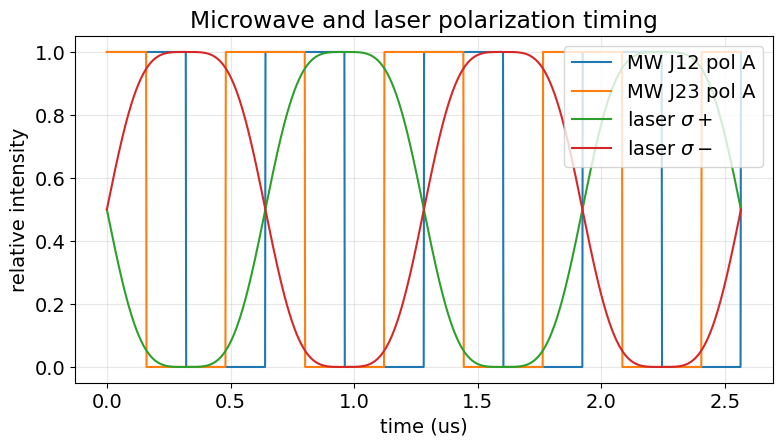

In [11]:
baseline_omega_mw = default_values["omega_mw_pol"] * Gamma
baseline_omega_laser = baseline_omega_mw / 2
diagnostic_t = np.linspace(0.0, 2 * (2 * np.pi / baseline_omega_laser), 1600)

mw12_a_values = np.asarray([square_wave(t, baseline_omega_mw, 0.0) for t in diagnostic_t])
mw23_a_values = np.asarray([square_wave(t, baseline_omega_mw, np.pi / 2) for t in diagnostic_t])
laser_sigma_p = np.asarray(
    [resonant_polarization_modulation(t, -np.pi / 2, baseline_omega_laser) for t in diagnostic_t]
)
laser_sigma_m = np.asarray(
    [resonant_polarization_modulation(t, np.pi / 2, baseline_omega_laser) for t in diagnostic_t]
)
laser_sigma_p_intensity = np.abs(laser_sigma_p) ** 2
laser_sigma_m_intensity = np.abs(laser_sigma_m) ** 2

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(1e6 * diagnostic_t, mw12_a_values, label="MW J12 pol A")
ax.plot(1e6 * diagnostic_t, mw23_a_values, label="MW J23 pol A")
ax.plot(1e6 * diagnostic_t, laser_sigma_p_intensity, label=r"laser $\sigma+$")
ax.plot(1e6 * diagnostic_t, laser_sigma_m_intensity, label=r"laser $\sigma-$")
ax.set_xlabel("time (us)")
ax.set_ylabel("relative intensity")
ax.set_title("Microwave and laser polarization timing")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.show()

## Baseline Evolution

Both systems are propagated at the top-level defaults: all Rabi rates and the microwave polarization switching frequency are `1 Gamma`.

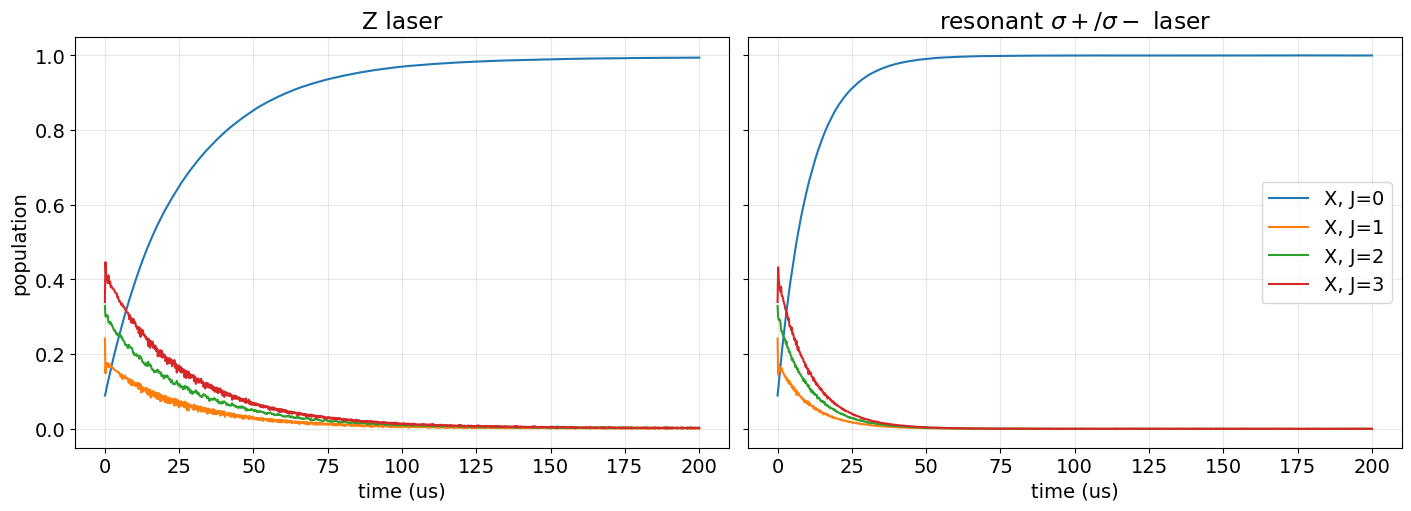

Final rotational population summary
Z laser
  X, J=0: 0.994363
  X, J=1: 0.000405
  X, J=2: 0.002425
  X, J=3: 0.002849
switched laser
  X, J=0: 1.000072
  X, J=1: 0.000209
  X, J=2: -0.000037
  X, J=3: -0.000245


In [10]:
baseline_evolution = solve_lindblad(
    baseline_prepared,
    rho0_baseline,
    (0.0, t_final),
    saveat=t_eval,
    output="populations",
    output_when="saveat",
    dense_output=True,
    collect_stats=True,
    **solver_options,
)
switched_evolution = solve_lindblad(
    switched_prepared,
    rho0_switched,
    (0.0, t_final),
    saveat=t_eval,
    output="populations",
    output_when="saveat",
    dense_output=True,
    collect_stats=True,
    **solver_options,
)

baseline_by_j = populations_by_j(baseline_evolution.values, baseline_system)
switched_by_j = populations_by_j(switched_evolution.values, switched_system)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True, constrained_layout=True)
for j_value, values in baseline_by_j.items():
    axes[0].plot(1e6 * baseline_evolution.t, values, label=f"X, J={j_value}")
for j_value, values in switched_by_j.items():
    axes[1].plot(1e6 * switched_evolution.t, values, label=f"X, J={j_value}")
axes[0].set_title("Z laser")
axes[1].set_title(r"resonant $\sigma+$/$\sigma-$ laser")
for ax in axes:
    ax.set_xlabel("time (us)")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("population")
axes[1].legend()
plt.show()

print("Final rotational population summary")
for label, evolution, system in [
    ("Z laser", baseline_evolution, baseline_system),
    ("switched laser", switched_evolution, switched_system),
]:
    print(label)
    for j_value, population in final_populations_by_j(evolution.values, system).items():
        print(f"  X, J={j_value}: {population:.6f}")

## Pairwise 2D Comparison Scans

Each slice scans two parameters from `0.1 Gamma` to `3 Gamma` with `25 x 25` points. The switched system derives the laser switching frequency from the scanned `omega_mw_pol`.

In [7]:
comparison_results = {}
comparison_best_points = []
for pair in scan_pairs:
    print(f"Running baseline slice: {pair[0]} vs {pair[1]}")
    baseline_slice = run_scan_slice(
        baseline_prepared,
        rho0_baseline,
        baseline_knobs,
        target_indices_baseline,
        pair,
    )
    print(f"Running switched slice: {pair[0]} vs {pair[1]}")
    switched_slice = run_scan_slice(
        switched_prepared,
        rho0_switched,
        switched_knobs,
        target_indices_switched,
        pair,
    )
    comparison_results[pair] = {
        "baseline": baseline_slice,
        "switched": switched_slice,
        "difference": switched_slice["grid"] - baseline_slice["grid"],
    }
    comparison_best_points.append({"mode": "Z laser", **best_point(baseline_slice)})
    comparison_best_points.append({"mode": "switched laser", **best_point(switched_slice)})
    print(comparison_best_points[-2])
    print(comparison_best_points[-1])

Running baseline slice: Omega_mw_12 vs Omega_mw_23
Running switched slice: Omega_mw_12 vs Omega_mw_23
{'mode': 'Z laser', 'slice': 'Omega_mw_12 vs Omega_mw_23', 'Omega_mw_12': np.float64(1.0666666666666667), 'Omega_mw_23': np.float64(0.42222222222222217), 'X,J=0': np.float64(0.9992196280663034), 'elapsed_s': 112.30575950001366}
{'mode': 'switched laser', 'slice': 'Omega_mw_12 vs Omega_mw_23', 'Omega_mw_12': np.float64(2.3555555555555556), 'Omega_mw_23': np.float64(1.711111111111111), 'X,J=0': np.float64(1.0003501027418498), 'elapsed_s': 92.50527710001916}
Running baseline slice: Omega_mw_12 vs Omega_laser
Running switched slice: Omega_mw_12 vs Omega_laser
{'mode': 'Z laser', 'slice': 'Omega_mw_12 vs Omega_laser', 'Omega_mw_12': np.float64(2.3555555555555556), 'Omega_laser': np.float64(3.0), 'X,J=0': np.float64(1.0003243233825323), 'elapsed_s': 83.0546622001566}
{'mode': 'switched laser', 'slice': 'Omega_mw_12 vs Omega_laser', 'Omega_mw_12': np.float64(3.0), 'Omega_laser': np.float64(1.

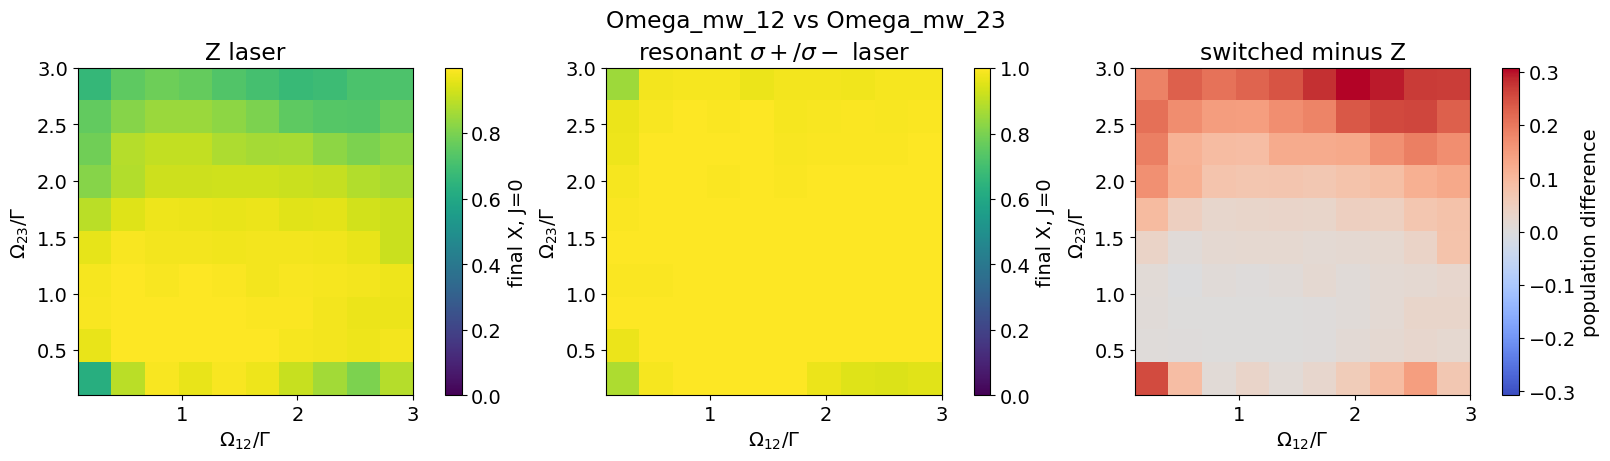

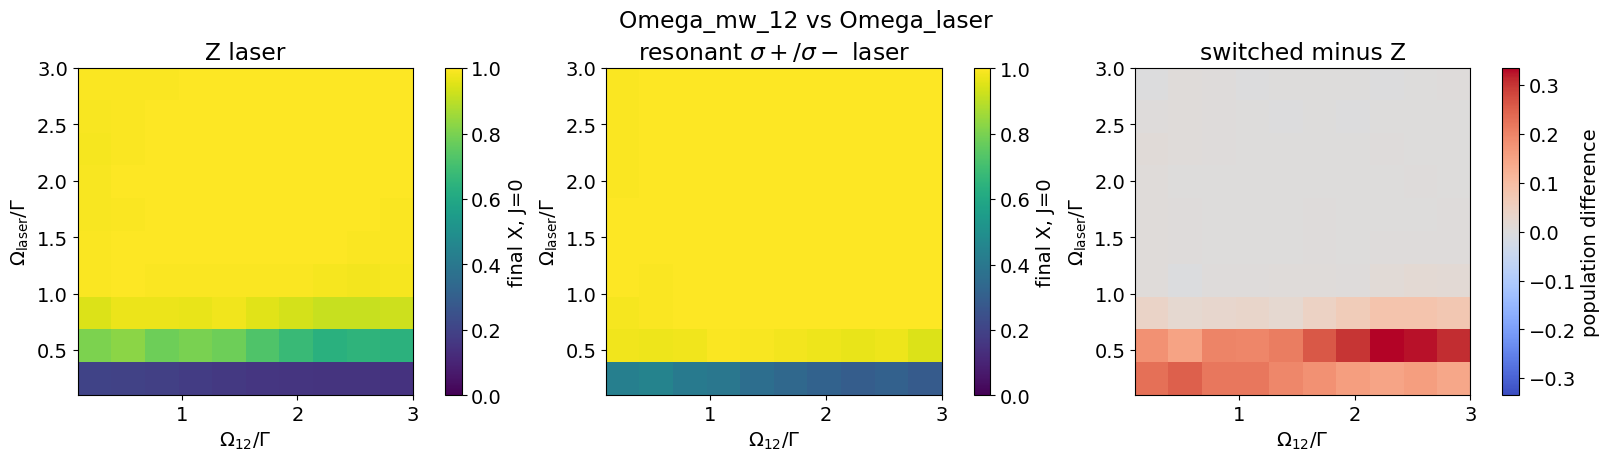

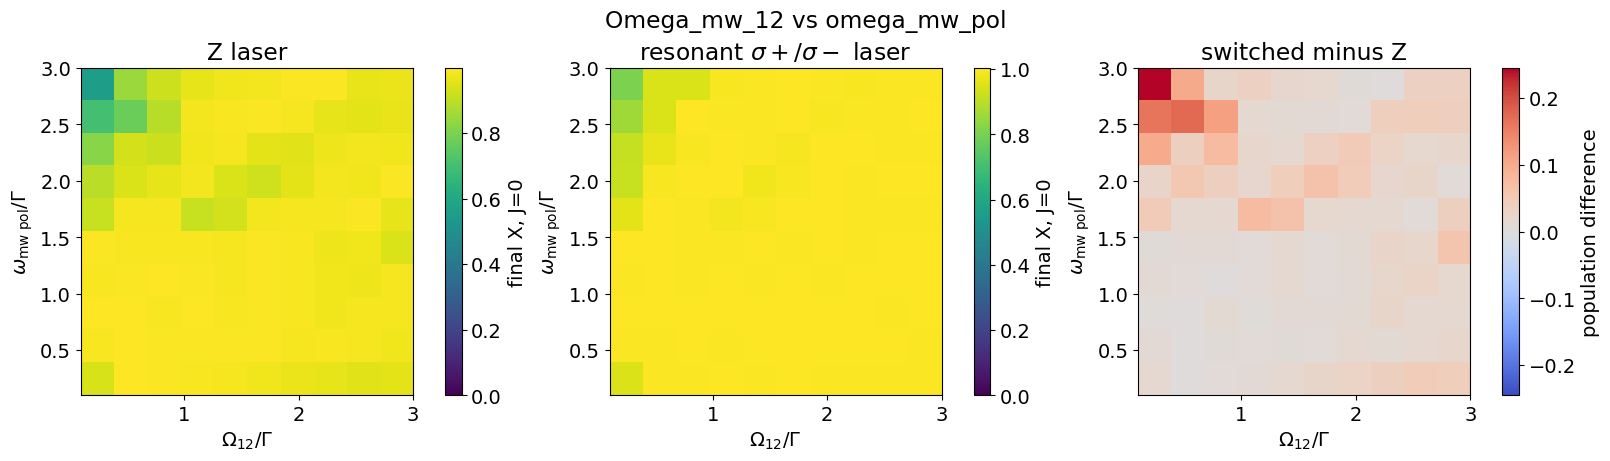

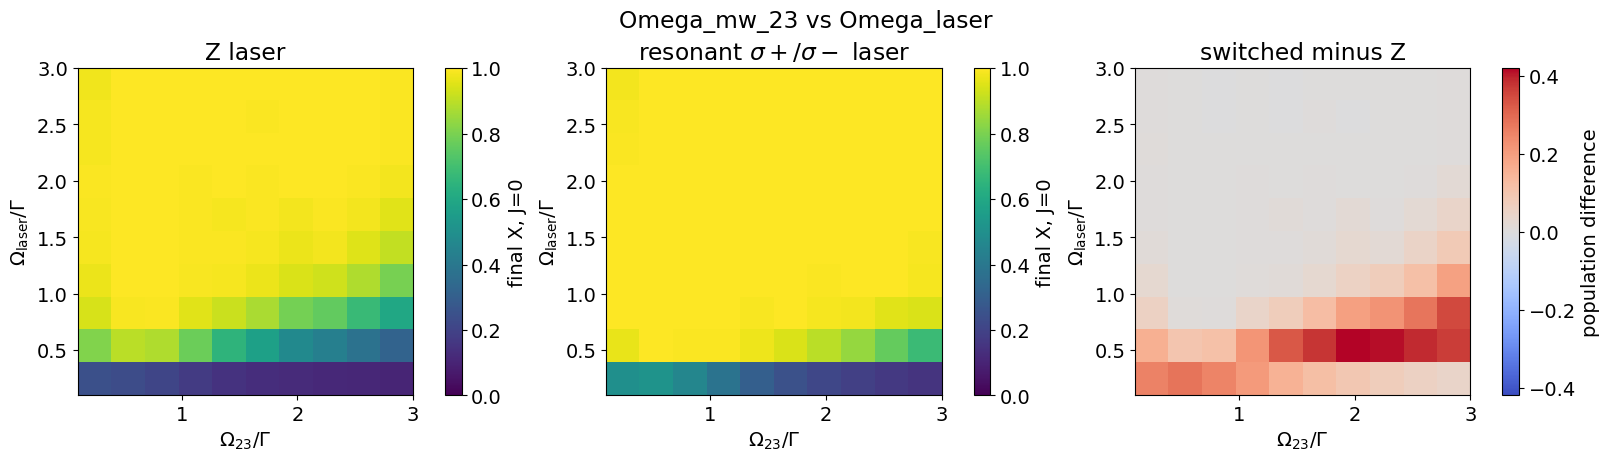

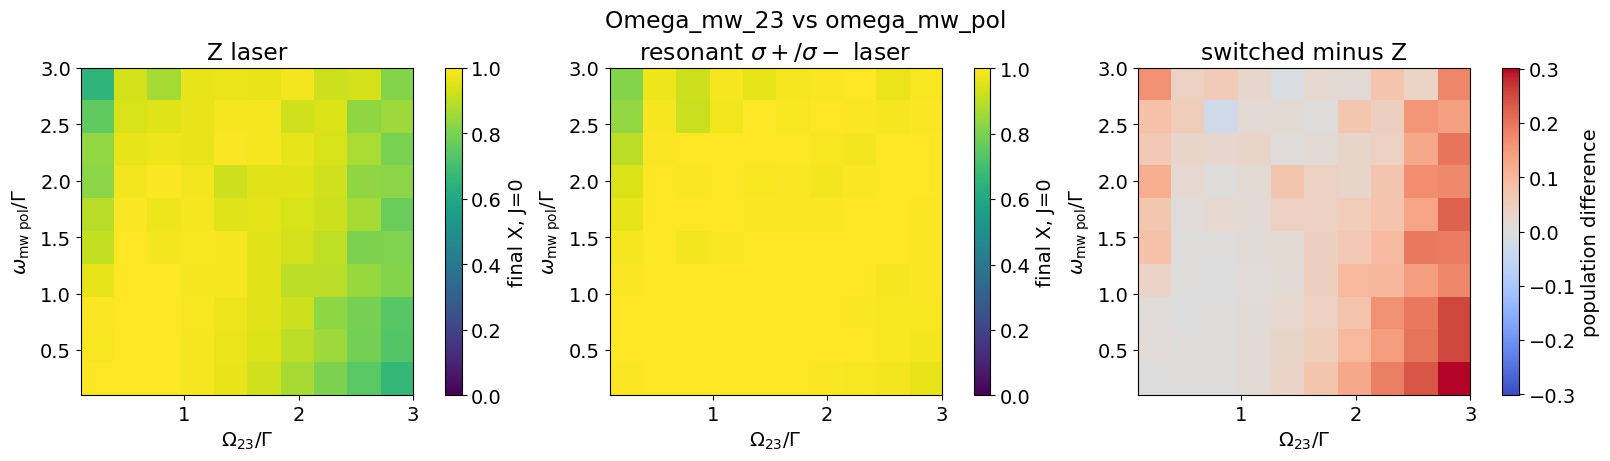

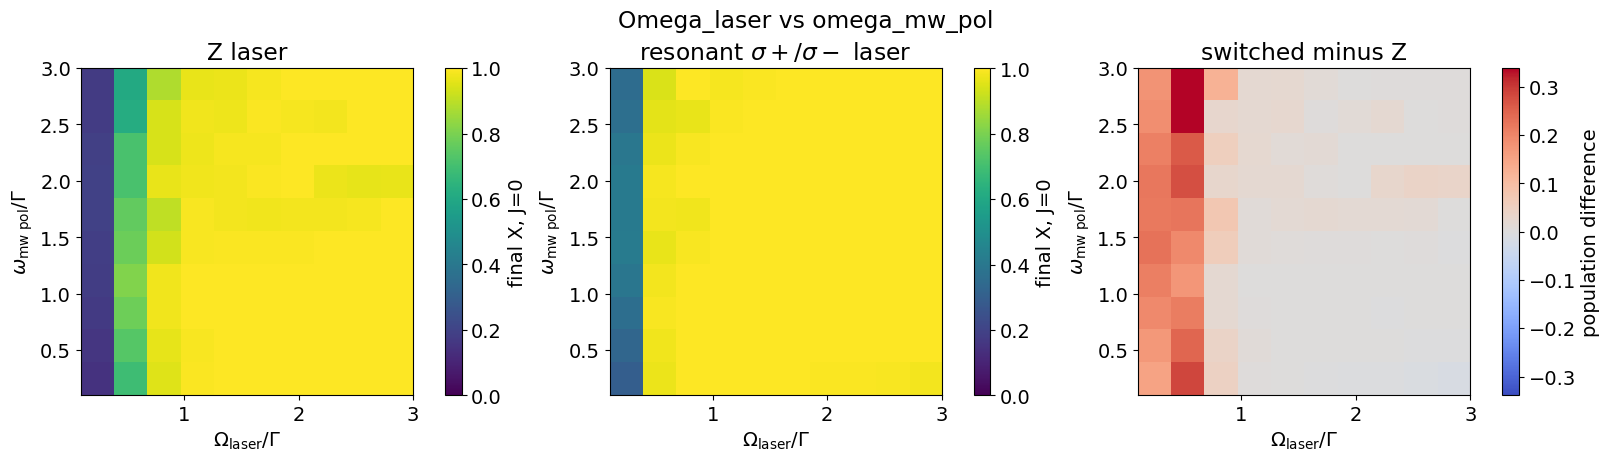

[{'mode': 'Z laser',
  'slice': 'Omega_mw_12 vs Omega_mw_23',
  'Omega_mw_12': np.float64(1.0666666666666667),
  'Omega_mw_23': np.float64(0.42222222222222217),
  'X,J=0': np.float64(0.9992196280663034),
  'elapsed_s': 112.30575950001366},
 {'mode': 'switched laser',
  'slice': 'Omega_mw_12 vs Omega_mw_23',
  'Omega_mw_12': np.float64(2.3555555555555556),
  'Omega_mw_23': np.float64(1.711111111111111),
  'X,J=0': np.float64(1.0003501027418498),
  'elapsed_s': 92.50527710001916},
 {'mode': 'Z laser',
  'slice': 'Omega_mw_12 vs Omega_laser',
  'Omega_mw_12': np.float64(2.3555555555555556),
  'Omega_laser': np.float64(3.0),
  'X,J=0': np.float64(1.0003243233825323),
  'elapsed_s': 83.0546622001566},
 {'mode': 'switched laser',
  'slice': 'Omega_mw_12 vs Omega_laser',
  'Omega_mw_12': np.float64(3.0),
  'Omega_laser': np.float64(1.0666666666666667),
  'X,J=0': np.float64(1.00107872770457),
  'elapsed_s': 76.33462239988148},
 {'mode': 'Z laser',
  'slice': 'Omega_mw_12 vs omega_mw_pol',
  '

In [8]:
for pair in scan_pairs:
    entry = comparison_results[pair]
    axis = entry["baseline"]["axis"]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
    image = heatmap(
        axes[0],
        entry["baseline"]["grid"],
        axis,
        axis,
        scan_definitions[pair[0]]["label"],
        scan_definitions[pair[1]]["label"],
        "Z laser",
    )
    fig.colorbar(image, ax=axes[0], label="final X, J=0")
    image = heatmap(
        axes[1],
        entry["switched"]["grid"],
        axis,
        axis,
        scan_definitions[pair[0]]["label"],
        scan_definitions[pair[1]]["label"],
        r"resonant $\sigma+$/$\sigma-$ laser",
    )
    fig.colorbar(image, ax=axes[1], label="final X, J=0")
    image = heatmap(
        axes[2],
        entry["difference"],
        axis,
        axis,
        scan_definitions[pair[0]]["label"],
        scan_definitions[pair[1]]["label"],
        "switched minus Z",
        diverging=True,
    )
    fig.colorbar(image, ax=axes[2], label="population difference")
    fig.suptitle(f"{pair[0]} vs {pair[1]}")
    plt.show()

comparison_best_points

## Notes

The microwave phase convention is unchanged from the square-wave-only notebook. In the switched-laser system, the laser switching frequency is tied to the microwave switching frequency rather than scanned independently: `omega_laser_pol = omega_mw_pol / 2`. That keeps the intended microwave phase relationship while making the laser polarization pass smoothly between `sigma+` and `sigma-`.